# Inverting the LDV data

In [1]:
import os

###############################################################################
# Decide on CPU or GPU here
use_gpu = False  # Set to False if you want CPU only
###############################################################################

if use_gpu:
    # Prevent JAX from preallocating most of the GPU memory
    os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
    # Force JAX to use GPU
    import jax
    jax.config.update("jax_platform_name", "gpu")
else:
    # Force JAX to use CPU
    import jax
    jax.config.update("jax_platform_name", "cpu")

In [3]:
from pathlib import Path
import numpy as np

from jax import jit, vjp, vmap, value_and_grad, random
import jax
from jax import numpy as jnp
from jax import lax
from jaxdf.operators import compose
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec
from IPython.display import display, clear_output

# from cmcrameri import cm

import optax
import equinox as eqx
from jax.example_libraries import optimizers
import time


from jwave.geometry import Domain, Medium
from jwave.signal_processing import smooth

key = random.PRNGKey(42)  # Random seed


from hybridoed.forward import create_src_field, generate_2D_gridded_src_rec_positions, ricker_wavelet, acoustic2D, acoustic2D_pml,acoustic2D_pml_minmem, acoustic2D_pml_4th_minmem, generate_src_rec_positions, acoustic2D_cpml_minmem

from hybridoed.oed import *

## Importing the LDV data

In [4]:
def _load_mat_v5(path):
    from scipy.io import loadmat
    # simplify_cells=True converts MATLAB structs/cell arrays into plain dicts/lists
    return loadmat(path, simplify_cells=True)

def _load_mat_v73(path):
    """
    Try mat73 first (best for structs). If unavailable, fall back to h5py
    to at least load numeric arrays.
    """
    try:
        import mat73  # pip install mat73
        return mat73.loadmat(path)
    except Exception:
        import h5py
        out = {}
        with h5py.File(path, "r") as f:
            for key in ["vib_x", "vib_y", "vib_z", "t", "XYZ", "index"]:
                if key in f:
                    out[key] = f[key][()]
        return out

def load_scan_mat(path, as_xarray=True):
    """
    Returns a dict with numpy arrays and, if as_xarray=True, an xarray.Dataset too.
    """
    path = Path(path).as_posix()

    # Detect v7.3 (HDF5) vs older MAT
    import h5py
    data = _load_mat_v73(path) if h5py.is_hdf5(path) else _load_mat_v5(path)

    # Extract main arrays
    vib_x = np.asarray(data["vib_x"])  # shape (n_pos, n_time)
    vib_y = np.asarray(data["vib_y"])
    vib_z = np.asarray(data["vib_z"])
    t     = np.asarray(data["t"]).ravel()         # (n_time,)
    XYZ   = np.asarray(data["XYZ"])               # (n_pos, 3)
    index = np.asarray(data.get("index", np.arange(vib_x.shape[0])+1)).ravel()  # MATLAB is 1-based

    # Optional structs (if you need them later)
    usd_x = data.get("usd_x", None)
    usd_y = data.get("usd_y", None)
    usd_z = data.get("usd_z", None)

    out = dict(
        vib_x=vib_x, vib_y=vib_y, vib_z=vib_z,
        t=t, XYZ=XYZ, index=index,
        usd_x=usd_x, usd_y=usd_y, usd_z=usd_z
    )

    if not as_xarray:
        return out

    # Build a convenient xarray Dataset
    try:
        import xarray as xr
        n_pos, n_time = vib_x.shape
        ds = xr.Dataset(
            coords={
                "pos":  ("pos", np.arange(n_pos, dtype=int)),
                "time": ("time", t),
                "x":    ("pos", XYZ[:, 0]),
                "y":    ("pos", XYZ[:, 1]),
                "z":    ("pos", XYZ[:, 2]),
                "index":("pos", index),
            },
            data_vars={
                "vib_x": (("pos", "time"), vib_x),
                "vib_y": (("pos", "time"), vib_y),
                "vib_z": (("pos", "time"), vib_z),
            },
            attrs={"source_file": Path(path).name},
        )
        out["dataset"] = ds
    except ImportError:
        pass

    return out

In [5]:
scan = load_scan_mat("../../grid_scan_dx_dy_1_5mm_fc_25kHz_fs_625kHz_100avg_1250nt_200V_scatter.mat")     # returns dict; scan["dataset"] if xarray is installed
ds = scan.get("dataset")

# Example: first position trace of vib_x
if ds is not None:
    import matplotlib.pyplot as plt
    plt.plot(ds["time"].values, ds["vib_x"].isel(pos=0).values)
    plt.xlabel("time (t)"); plt.ylabel("vib_x amplitude"); plt.show()

In [6]:
vib_z = scan["vib_z"]
vib_y = scan["vib_y"]
vib_x = scan["vib_x"]
usd_x = scan["usd_x"]
t = scan["t"]
XYZ = scan["XYZ"]


In [7]:
print(vib_z.shape,t.shape,XYZ.shape)
print("time step duration:", t[1]-t[0])

(11229, 938) (938,) (11229, 3)
time step duration: 1.6e-06


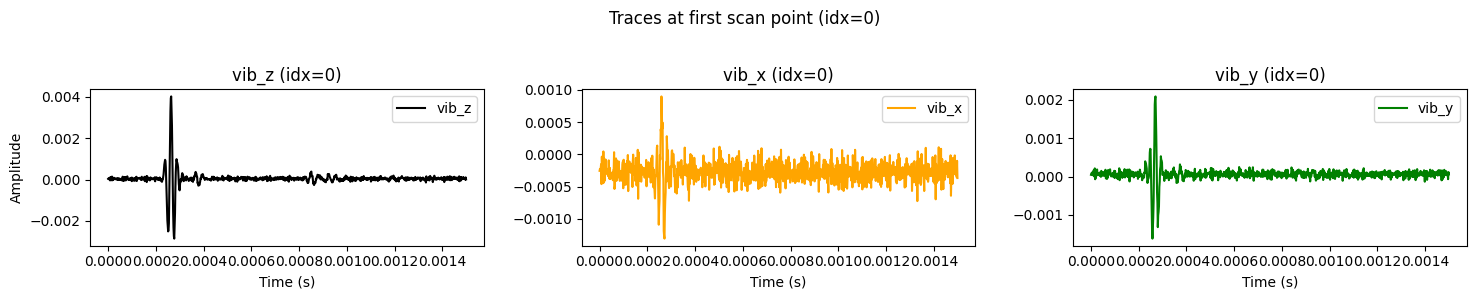

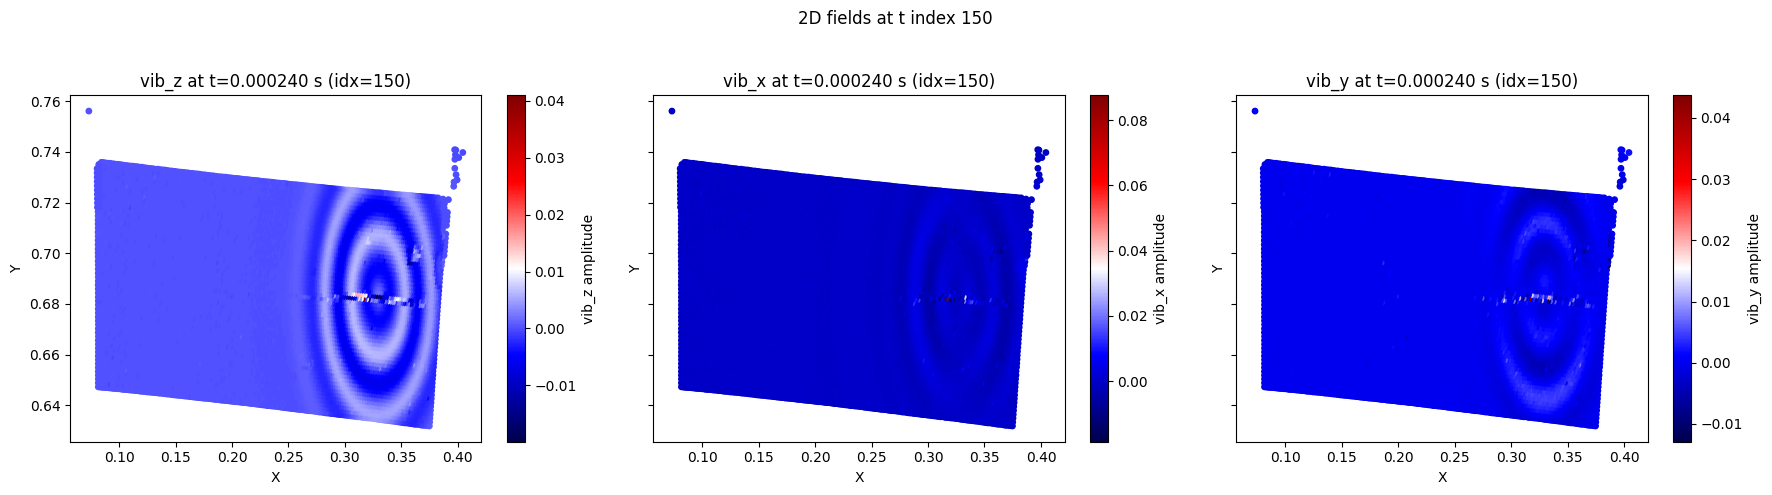

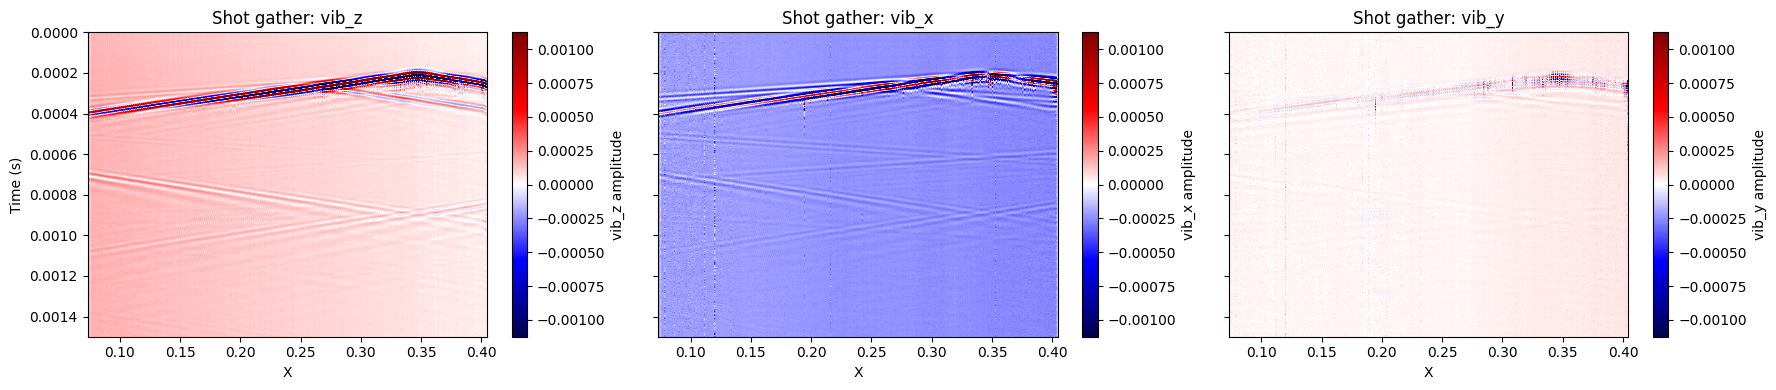

In [13]:
# for a few time in the vib_z plot the evoluation of the 2D field with the XYZ. each point in a single time step of the vib_z as a cordinate in XYZ

# Example: Plotting the first trace of vib_z
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15, 3), sharex=True)
axes[0].plot(t, vib_z[0, :], color="k", label="vib_z")
axes[0].set_title("vib_z (idx=0)")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude")
axes[0].legend()

axes[1].plot(t, vib_x[0, :], color="orange", label="vib_x")
axes[1].set_title("vib_x (idx=0)")
axes[1].set_xlabel("Time (s)")
axes[1].legend()

axes[2].plot(t, vib_y[0, :], color="green", label="vib_y")
axes[2].set_title("vib_y (idx=0)")
axes[2].set_xlabel("Time (s)")
axes[2].legend()

fig.suptitle("Traces at first scan point (idx=0)")
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Plot the 2D field for several selected time steps to visualize the evolution. Each scanning point is 1.5mm apart in a grid.

# plot vib_z, vib_x, vib_y at a single time index in one row
idx = 150
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

data_list = [vib_z[:, idx], vib_x[:, idx], vib_y[:, idx]]
titles = [
    f"vib_z at t={t[idx]:.6f} s (idx={idx})",
    f"vib_x at t={t[idx]:.6f} s (idx={idx})",
    f"vib_y at t={t[idx]:.6f} s (idx={idx})",
]
labels = ["vib_z amplitude", "vib_x amplitude", "vib_y amplitude"]

for ax, data, title, label in zip(axes, data_list, titles, labels):
    sc = ax.scatter(XYZ[:, 0], XYZ[:, 1], c=data, cmap="seismic", s=15)
    ax.set_title(title)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    fig.colorbar(sc, ax=ax, label=label)

fig.suptitle(f"2D fields at t index {idx}")
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()



# make a shotgather type of plot whre the y axis is time and the x axis is space
# single-row shotgather for vib_z, vib_x, vib_y (time on y, space on x)
s = XYZ[:, 0] 
idx = np.argsort(s)
vmax = max(np.max(np.abs(vib_z)), np.max(np.abs(vib_x)), np.max(np.abs(vib_y))) / 1e2

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)
fields = [vib_z, vib_x, vib_y]
titles = ["vib_z", "vib_x", "vib_y"]

for ax, field, title in zip(axes, fields, titles):
    im = ax.imshow(
        field[idx, :].T,
        extent=[s[idx].min(), s[idx].max(), t.max(), t.min()],
        origin="upper",
        aspect="auto",
        cmap="seismic",
        vmin=-vmax,
        vmax=vmax,
    )
    ax.set_title(f"Shot gather: {title}")
    ax.set_xlabel("X")
    if ax is axes[0]:
        ax.set_ylabel("Time (s)")
    fig.colorbar(im, ax=ax, label=f"{title} amplitude")

fig.tight_layout()
plt.show()


## Forward model

In [14]:


# ---- physical domain (meters) ----
Lx, Ly = 0.4, 0.4               # FIXED domain size
c_min = c_max = 2750.0            # plexiglass (m/s)

# ---- resolution chosen ONCE for the highest test frequency ----
f0_max = 25e3                     # highest center freq you'll run
fmax   = 2.0 * f0_max             # Ricker top-end
PPW    = 10                       # for 2nd-order space; 10–12 is typical

dx_req = c_min / (PPW * fmax)
dx = dy = dx_req                  # keep this fixed for all runs

# grid size from physical size
nx = int(np.floor(Lx / dx)) + 1
ny = int(np.floor(Ly / dy)) + 1
dx = Lx / (nx - 1)                # snap dx to fit exactly
dy = Ly / (ny - 1)

print(f"nx, ny = {nx}, {ny}  |  dx = {dx*1e3:.2f} mm, dy = {dy*1e3:.2f} mm")

# ---- stable time step (keep FIXED) ----
dt_max = min(dx,dy) / (c_max * np.sqrt(2.0))   # 2-D CFL for staggered first-order
dt = 0.8 * dt_max                              # margin
print(f"dt = {dt*1e6:.2f} µs")

# ---- PML thickness in METERS (fixed), converted to cells ----
pml_thickness_m = 0.01                         # e.g., 3 cm per side
pml_width = max(4, int(round(pml_thickness_m / dx)))
print(f"pml_width = {pml_width} cells (~{pml_width*dx*100:.1f} cm)")

# ---- material model (fixed in meters) ----
velocity = 2750.0
density  = 1000.0

true_model = jnp.full((nx, ny), velocity, dtype=jnp.float32)

# scatterer defined in METERS, then mapped to indices
scx0, scx1 = 0.198, 0.202    # x-extent in m (example)
scy0, scy1 = 0.15, 0.154    # y-extent in m (example)
ix0, ix1 = int(scx0/dx), int(scx1/dx)
iy0, iy1 = int(scy0/dy), int(scy1/dy)
true_model = true_model.at[ix0:ix1, iy0:iy1].set(velocity * 1.5)

density_grid = jnp.full_like(true_model, density)

# ---- geometry in METERS (then to index floats) ----
# One source 2 cm from left wall, centered vertically
src_x_m, src_y_m = 0.195, 0.55*Ly

src_idx = jnp.array([src_x_m / dx, src_y_m / dy], dtype=jnp.float32)

# 2D grid of receivers: 
n_rx, n_ry = 50, 50
rec_x_m = np.linspace(0.02, Lx/5 - 0.02, n_rx) + 0.15
rec_y_m = np.linspace(0.02, Ly/2.5 - 0.02, n_ry) + 0.1
rec_xx, rec_yy = np.meshgrid(rec_x_m, rec_y_m, indexing='ij')
receiver_is = jnp.stack([rec_xx.ravel() / dx, rec_yy.ravel() / dy], axis=1).astype(jnp.float32)

# ---- time window FIXED in seconds ----
T = 0.00015                     # e.g., 120 µs fixed
n_steps = int(np.ceil(T / dt))
print(f"n_steps = {n_steps}, total time = {n_steps*dt*1e6:.1f} µs")

# ---- run for any f0 (ONLY f0 changes) ----
f0 = 50e3  # try 10e3, 25e3, 40e3 without changing grid/dt
ys = acoustic2D_cpml_minmem(
    true_model, density_grid, src_idx, f0,
    dx, dy, dt, n_steps,
    receiver_is=receiver_is,
    output_wavefield=True,
    pml_width=pml_width,
    R_coeff=1e-6, m=3, kappa_max=3.0, alpha_max=None
)
seis = ys[0]  # (n_steps, Nrec)
wavefields_test = ys[1]  # (n_steps, nx, ny)


nx, ny = 73, 73  |  dx = 5.56 mm, dy = 5.56 mm
dt = 1.14 µs
pml_width = 4 cells (~2.2 cm)
n_steps = 132, total time = 150.8 µs


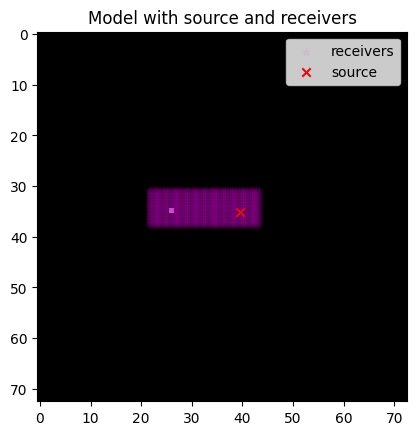

In [15]:
plt.scatter(receiver_is[:,1], receiver_is[:,0], c="m", marker="*", label="receivers", alpha=0.03)
plt.scatter(src_idx[1], src_idx[0], c="r", marker="x", label="source")
plt.imshow(true_model,cmap='grey')
plt.legend()
plt.title("Model with source and receivers")
plt.show()

In [16]:
# make a shot gather with the x axis being the y position
# sorte the trace by y position
source_x, source_y = src_idx
receiver_x, receiver_y = receiver_is[:,0], receiver_is[:,1]
sorted_indices_y = np.argsort(receiver_y)
sorted_offsets_y = receiver_y[sorted_indices_y]
sorted_traces_y = seis[:, sorted_indices_y]
n_traces_y = sorted_traces_y.shape[1]
n_samples_y = sorted_traces_y.shape[0]

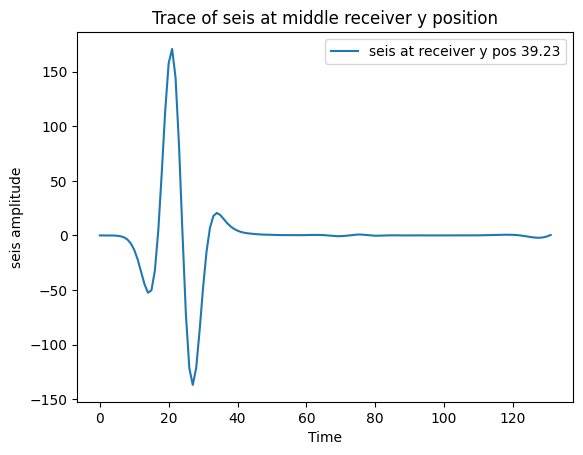

In [17]:
# plot single trace of for a single y position
# trace_idx = n_traces_y // 2  # middle trace
trace_idx = 2000
plt.figure()
plt.plot(np.arange(n_samples_y), sorted_traces_y[:, trace_idx], label=f"seis at receiver y pos {sorted_offsets_y[trace_idx]:.2f}")
plt.xlabel("Time")
plt.ylabel("seis amplitude")
# plt.ylim(-10, 10)
# plt.xlim(40, n_samples_y)
plt.title("Trace of seis at middle receiver y position")
plt.legend()
plt.show()